**Metric**
- A macro-averaged ROC-AUC metric (with the adjustment to skip classes with no true positive labels) for several important reasons:

1. Handling Class Imbalance
Equal Importance: Macro-averaging computes the ROC-AUC independently for each class and then averages the results. This approach ensures that every class is given equal weight—even those with few examples. In biodiversity datasets, where some species may be rare, this is crucial.

Avoiding Misleading Averages: By skipping classes without true positives, the metric prevents penalizing the model for not predicting classes that are absent or extremely underrepresented in the ground truth. This helps avoid distortions in the evaluation due to extreme class imbalance.

2. Threshold Independence
Continuous Performance Assessment: The ROC-AUC metric evaluates the model's ability to rank predictions correctly over a range of thresholds. This is beneficial in cases where the optimal threshold for decision-making is not known beforehand, as it provides a comprehensive view of model performance.

3. Robustness in Diverse Datasets
Applicability to Ecological Data: Given the complex and noisy nature of acoustic data in ecological monitoring, ROC-AUC offers a stable and reliable measure. It captures the trade-off between true positive and false positive rates without being affected by the exact decision threshold.

- Accuracy

**Predictions**  

For each row_id, we predict the probability that a given species was present. There is one column per species. Each row covers a 3-second window of audio.

**Training Data**  
- Species Classifiction
- Genus/Family classification
- Species Detection (class) = questionable!

Focus on this.
- Call type classification ( call or buzz(song))
- Captioning (prediction)

Audio Input- Audio encoder - Windowing and Librosa/Q-Former/CNN/RL - Audio Embeddings - Prediction

Audio Input: The raw audio is captured.

Audio Encoder: The audio is transformed into a more useful form (e.g., MFCCs, spectrogram).

Windowing: The signal is divided into smaller windows to analyze local features.

Q-Former: A transformer-based model processes the features to capture long-range dependencies.  

CNN:

Reinforcment Learning:

Audio Embeddings: The model outputs a fixed-length vector representation of the audio.

Prediction: The embeddings are used to make a final prediction (classification or regression).

The most common audio file formats include:

Lossy Formats (compressed with some quality loss)
- MP3 (.mp3)
Most common audio format; widely supported, small file sizes, suitable for streaming and sharing.

- AAC (.aac or .m4a)
Improved quality over MP3 at similar bitrates; commonly used by Apple (iTunes, Apple Music).

- OGG Vorbis (.ogg)
Open-source format with good compression and audio quality; popular on streaming platforms.

- WMA (.wma)
Developed by Microsoft; declining in popularity but still common on Windows platforms.

Lossless Formats (compressed without losing quality)
- FLAC (.flac)
Widely popular among audiophiles for archiving high-quality audio without losing fidelity; compatible with many modern devices.

- ALAC (.m4a)
Apple's lossless audio format; supported across Apple devices and increasingly popular among audiophiles.

Uncompressed Formats
- WAV (.wav)
High-quality, uncompressed audio format common in professional audio production and editing.

- AIFF (.aiff, .aif)
Uncompressed format used primarily on Apple systems and by audio professionals.

- Mono channel (1 channel):

Consistency; easier to handle, reduces dimensionality.

Most audio analysis algorithms expect mono inputs.

- Sample rate (44.1 kHz):

Standard across many audio ML libraries.

Balances data quality and processing speed.

- Bit depth (16-bit PCM):

Standard for good audio quality, sufficient for ML.

**audiomentation**     
Augment audio dat: creating slightly modified versions of your original audio clips to improve the robustness and generalization of your machine learning model.

Augmentation	Description
- AddGaussianNoise	Adds random noise to simulate real-world background
- TimeStretch	Speeds up or slows down the audio
- PitchShift	Shifts the pitch up or down (without changing speed)
- Shift	Moves the audio forward or backward in time
- ClippingDistortion	Simulates audio distortion by clipping the waveform
- Gain	Increases or decreases the volume
- HighPassFilter / LowPassFilter	Filters out low or high frequencies
- PolarityInversion	Flips waveform upside down (not audible but changes signal)

In [1]:
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pydub import AudioSegment
import wave
import math
import soundfile as sf
import librosa
from audiomentations import Compose, AddGaussianNoise, TimeStretch, PitchShift, Shift
from pathlib import Path
from tqdm import tqdm
from IPython.display import Audio, display
import shutil
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.transforms as transforms
from collections import defaultdict
from PIL import Image
import gc
import psutil
import tracemalloc
import time
import hdbscan
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import seaborn as sns

c:\Users\shang\Programs\anaconda3\Lib\site-packages\torch\utils\_pytree.py:185: FutureWarning: optree is installed but the version is too old to support PyTorch Dynamo in C++ pytree. C++ pytree support is disabled. Please consider upgrading optree using `python3 -m pip install --upgrade 'optree>=0.13.0'`.
  warnings.warn(


Defining functions

In [ ]:
# # Utility: Log memory usage
# def log_memory(tag=""):
#     process = psutil.Process(os.getpid())
#     mem_mb = process.memory_info().rss / (1024 * 1024)
#     print(f"[{time.strftime('%H:%M:%S')}] {tag} | RAM: {mem_mb:.2f} MB")

In [ ]:
# a function to print the properties of an audio file
def f_get_properties(filename): 
    with wave.open(filename, 'rb') as wav_file:
        num_channels = wav_file.getnchannels()
        sample_rate = wav_file.getframerate()
        sample_width = wav_file.getsampwidth()
        num_frames = wav_file.getnframes()
        duration = num_frames / float(sample_rate)
        bit_depth = sample_width * 8  # Sample width is in bytes
    return num_channels, sample_rate, bit_depth, duration

In [4]:
def f_convert_and_normalize_audio(
    dir_source="audio_input",
    dir_wav="audio_wav",
    dir_target="audio_output",
    target_sr=44100,
    subtype="PCM_16",
    mono=True
):
    """
    Converts audio files from multiple formats to WAV, then normalizes them
    to mono, 44.1kHz sample rate, and 16-bit PCM.
    Frees up space by deleting intermediate WAVs after normalization.
    """
    # Create directories if needed
   
    os.makedirs(dir_wav, exist_ok=True)
    os.makedirs(dir_target, exist_ok=True)

    # Step 1: Converting all formats to WAV.
    for file_name in os.listdir(dir_source):
        if file_name.lower().endswith((
            ".mp3", ".ogg", ".flac", ".aac", ".m4a", ".wma",
            ".aif", ".aiff", ".mp4", ".mpga", ".wav"
        )):
            input_path = os.path.join(dir_source, file_name)
            output_path = os.path.join(dir_wav, os.path.splitext(file_name)[0] + ".wav")

            try:
                audio = AudioSegment.from_file(input_path)
                audio.export(output_path, format="wav")
            except Exception as e:
                print(f"Failed to convert {file_name}: {e}")

    # Step 2: Normalizing WAVs to mono, 44.1kHz, 16-bit PCM
    for file_name in os.listdir(dir_wav):
        input_path = os.path.join(dir_wav, file_name)
        output_path = Path(dir_target) / file_name

        try:
            samples, sr = librosa.load(input_path, sr=target_sr, mono=mono)
            sf.write(output_path, samples, samplerate=target_sr, subtype=subtype)

            # Delete intermediate .wav to save space
            os.remove(input_path)

        except Exception as e:
            print(f"Could not normalize {file_name}: {e}")

    print("All audio files processed and saved to:", dir_target)

    # Clean up intermediary folders if empty
    try:
        os.rmdir(dir_wav)
        print(f"Removed temporary folder: {dir_wav}")
    except OSError:
        print(f"Could not remove {dir_wav} (not empty or in use).")


In [5]:
def f_audio_clean(y, threshold_db=-35):
    """
    Determines if the audio chunk contains meaningful sound based on RMS energy.
    """
    if not isinstance(y, np.ndarray):
        y = np.array(y).astype(np.float32)
    rms = librosa.feature.rms(y=y)[0]
    db = librosa.amplitude_to_db(rms, ref=np.max)
    percent_below = np.mean(db < threshold_db)
    return percent_below < 0.9


In [6]:
def f_split(input_folder="audio_output", duration=3):

    """
    Splits pre-normalized WAV files into chunks of fixed duration,
    padding the final chunk with silence if it's too short.
    Moves non-meaningful audio files to a _skipped folder.
    Deletes input files and folder after processing.

    """
    output_folder_split = f"{input_folder}_{duration}" # Create output folder name
    output_folder_skipped = f"{output_folder_split}_skipped" # Create skipped folder name
    os.makedirs(output_folder_split, exist_ok=True)
    os.makedirs(output_folder_skipped, exist_ok=True)

    chunk_length_ms = duration * 1000

    for audio_file in os.listdir(input_folder):
        if audio_file.lower().endswith(".wav"):
            input_path = os.path.join(input_folder, audio_file)
            audio = AudioSegment.from_wav(input_path)
            total_length_ms = len(audio)
            num_chunks = math.ceil(total_length_ms / chunk_length_ms)
            base_name = os.path.splitext(audio_file)[0]

            for i in range(num_chunks):
                start_ms = i * chunk_length_ms
                end_ms = start_ms + chunk_length_ms
                chunk_audio = audio[start_ms:end_ms]

                # Pad if needed
                if len(chunk_audio) < chunk_length_ms:
                    padding = AudioSegment.silent(duration=chunk_length_ms - len(chunk_audio))
                    chunk_audio += padding
                chunk_audio = chunk_audio[:chunk_length_ms]

                # Calculate time boundaries in seconds
                start_sec = int(start_ms / 1000)
                end_sec = int(start_sec + duration)

                chunk_filename = os.path.join(
                    output_folder_split,
                    f"{base_name}_{start_sec:03d}_{end_sec:03d}.wav"
                )

                # Export first, then check meaningfulness
                chunk_audio.export(chunk_filename, format="wav")
                y = np.array(chunk_audio.get_array_of_samples()).astype(np.float32)

                if not f_audio_clean(y):
                    os.rename(chunk_filename, os.path.join(output_folder_skipped, os.path.basename(chunk_filename)))
            # Delete the processed file
            os.remove(input_path)

    # Delete the input folder after all files are processed
    os.rmdir(input_folder)

    print(f"Split and cleaned audio into {output_folder_split}")
    print(f"Skipped audio saved in {output_folder_skipped}")
    print(f"Deleted folder: {input_folder}")

In [7]:
def process_audio_files(input_folder, duration=3): 
    """
    Full audio processing:
    1. Convert and normalize to WAV format.
    2. Split into chunks of specified duration and filter silence.
    """
    f_convert_and_normalize_audio(dir_source=input_folder)
    f_split(input_folder="audio_output", duration=duration)

Augmenting audio data   

In [9]:
def f_audio_augment(
    source_dir,
    output_dir,
    max_per_class=100,
    augment=None
):
    """
    Augments pre-normalized, chunked 3-second .wav files until each class reaches `max_per_class`.

    Args:
        source_dir (str): Path to labeled class folders with 3-sec WAV files.
        output_dir (str): Where to save augmented WAVs.
        max_per_class (int): Max total number of segments (original + augmented) per class.
        augment (Compose or None): Audiomentations pipeline.
    """
    output_dir = f"{source_dir}_augmented" # Create output folder name
    os.makedirs(output_dir, exist_ok=True)
    class_counts = defaultdict(int)
    class_segments = defaultdict(list)

    # Default augmentation pipeline
    if augment is None:
        augment = Compose([
            AddGaussianNoise(min_amplitude=0.001, max_amplitude=0.015, p=0.7),
            TimeStretch(min_rate=0.95, max_rate=1.05, p=0.6),
            PitchShift(min_semitones=-1, max_semitones=1, p=0.3),
            Shift(min_shift=-0.1, max_shift=0.1, p=0.8)
        ])

    for file_path in Path(source_dir).rglob("*.wav"):
        label = file_path.parent.name
        samples, sample_rate = sf.read(file_path)

        class_counts[label] += 1
        class_segments[label].append((file_path.stem, samples, sample_rate))

    # Print class distribution BEFORE augmentation
    print("\n Original Class Distribution:")
    for label, count in class_counts.items():
        print(f" - {label:<10}: {count} segments")


    for label, segments in class_segments.items():
        aug_idx = 0
        while class_counts[label] < max_per_class:
            for stem, samples, sr in segments:
                if class_counts[label] >= max_per_class:
                    break
                augmented = augment(samples=np.asarray(samples, dtype=np.float32), sample_rate=sr)
                aug_name = f"{label}_{stem}_aug{aug_idx}.wav"
                augmented_subfolder = os.path.join(output_dir, f"{label}_augmented")
                os.makedirs(augmented_subfolder, exist_ok=True)

                out_path = os.path.join(augmented_subfolder, aug_name)
                sf.write(out_path, augmented, sr, subtype="PCM_16")
                class_counts[label] += 1
            aug_idx += 1

    print("\n Augmentation complete.")
    print(" Final Segment Counts Per Class:")
    for label, count in class_counts.items():
        print(f"{label:<10} --> {count} samples")

In [10]:
##f_audio_augment("audio_data")

In [ ]:
class SpectrogramEmbedder(nn.Module):
    """
    A simple CNN-based model that encodes 2D mel spectrograms into fixed-length embedding vectors.
    Architecture:
        - 3 convolutional layers with ReLU and pooling
        - Adaptive average pooling to reduce spatial dimensions
        - Fully connected layer to produce the final embedding
    Args:
        embedding_dim (int): Dimension of the output embedding vector (default: 128)
    Input:
        Tensor of shape (batch_size, 1, height, width)
    Output:
        Tensor of shape (batch_size, embedding_dim)
    """
    def __init__(self, embedding_dim=128):
        super().__init__()
        self.cnn = nn.Sequential(
            nn.Conv2d(1, 16, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(16, 32, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1), nn.ReLU(), nn.AdaptiveAvgPool2d(1)
        )
        self.fc = nn.Linear(64, embedding_dim)

    def forward(self, x):
        x = self.cnn(x).view(x.size(0), -1)
        return self.fc(x)

In [ ]:
def extract_features(y, sr, n_mfcc):
    """
    Extracts  audio features from a waveform, including:
    chroma (12), spectral centroid, bandwidth, rolloff, zero-crossing rate,
    and MFCCs (n_mfcc), all averaged over time.
    """
    return np.concatenate([
        np.mean(librosa.feature.chroma_stft(y=y, sr=sr), axis=1),
        [np.mean(librosa.feature.spectral_centroid(y=y, sr=sr))],
        [np.mean(librosa.feature.spectral_bandwidth(y=y, sr=sr))],
        [np.mean(librosa.feature.spectral_rolloff(y=y, sr=sr))],
        [np.mean(librosa.feature.zero_crossing_rate(y))],
        np.mean(librosa.feature.mfcc(y=y, sr=sr, n_mfcc=n_mfcc), axis=1)
    ])

def extract_embedding(y, sr, model, n_mels, img_size):
    """
    Converts an audio waveform into a mel spectrogram,
    resizes it to a square tensor, normalizes it,
    and passes it through a pretrained model to extract an embedding vector.
    """
    mel_db = librosa.power_to_db(librosa.feature.melspectrogram(y=y, sr=sr, n_mels=n_mels), ref=np.max)
    mel_tensor = torch.tensor(mel_db, dtype=torch.float32).unsqueeze(0).unsqueeze(0).float()
    mel_tensor = (mel_tensor - mel_tensor.min()) / (mel_tensor.max() - mel_tensor.min() + 1e-6)
    mel_resized = F.interpolate(mel_tensor, size=(img_size, img_size), mode='bilinear')
    
    with torch.no_grad():
        return model(mel_resized).squeeze().numpy()

def extract_combined_features_and_embeddings(
    input_folder, model, sr=44100, n_mfcc=13, n_mels=128, img_size=224, max_files=None
):
    """
    Processes all WAV files in a folder, extracting both librosa audio features
    and deep embeddings, and returns a DataFrame with one row per file.
    
    """
    
    columns = (
        ['filename'] +  # <-- move filename to the start
        [f'chroma_{i}' for i in range(12)] +
        ['centroid', 'bandwidth', 'rolloff', 'zcr'] +
        [f'mfcc_{i}' for i in range(n_mfcc)] +
        [f'emb_{i}' for i in range(model.fc.out_features)]
    )

    rows, files = [], [f for f in os.listdir(input_folder) if f.endswith(".wav")]
    for i, fname in enumerate(files):
        if max_files and i >= max_files:
            break

        path = os.path.join(input_folder, fname)
        try:
            y, sr_actual = librosa.load(path, sr=sr, mono=True)
            features = extract_features(y, sr_actual, n_mfcc)
            embedding = extract_embedding(y, sr_actual, model, n_mels, img_size)
            rows.append(np.concatenate([[fname], features, embedding]))  # <-- filename first
        except Exception as e:
            print(f"Error processing {fname}: {e}")
        finally:
            gc.collect()

    return pd.DataFrame(rows, columns=columns)

In [14]:
if __name__ == "__main__":
    input_folder = "./audio_input"
    model = SpectrogramEmbedder(embedding_dim=128)
    model.eval()
    df = extract_combined_features_and_embeddings(input_folder, model)
    df.to_csv("combined_audio_dataset.csv", index=False)

c:\Users\shang\Programs\anaconda3\Lib\site-packages\librosa\core\pitch.py:101: UserWarning: Trying to estimate tuning from empty frequency set.
  return pitch_tuning(


Clustering

In [ ]:
df = pd.read_csv("INPUT.csv")

X = df.drop(columns=["filename"]).values

In [ ]:
# normalize the data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [17]:
clusterer = hdbscan.HDBSCAN(min_cluster_size=10)
labels = clusterer.fit_predict(X_scaled)

In [18]:
# Count how many clusters (excluding noise = -1)
n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
print(f"Found {n_clusters} clusters")

# Optional: see how many noise points
n_noise = np.sum(labels == -1)
print(f"{n_noise} noise points")

Found 2 clusters
183 noise points


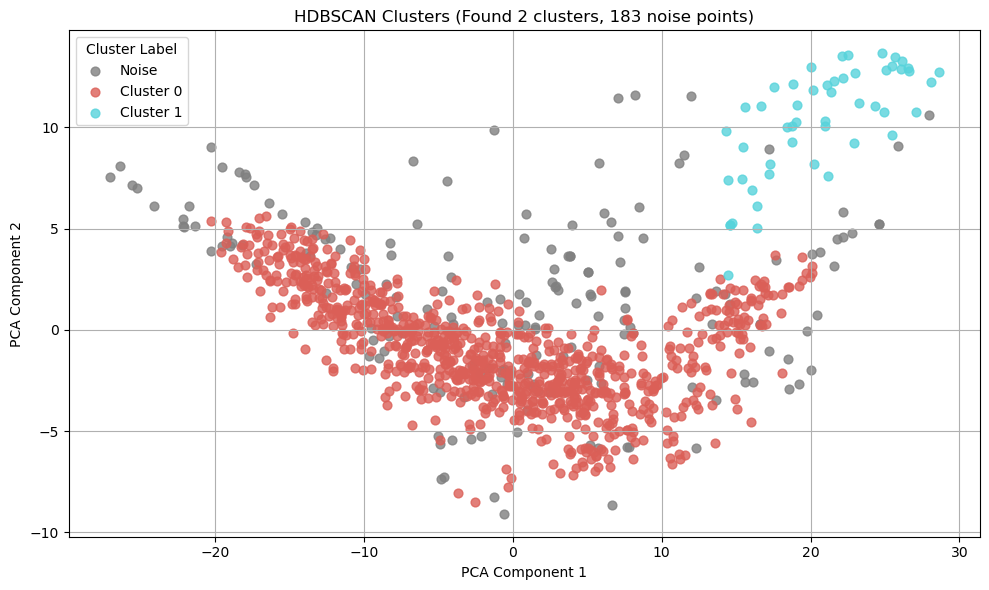

In [ ]:
# Reduce to 2D
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Get unique labels and palette
unique_labels = sorted(set(labels))
n_clusters = len([l for l in unique_labels if l != -1])
palette = sns.color_palette("hls", n_clusters)
color_map = {label: palette[i] for i, label in enumerate(l for l in unique_labels if l != -1)}
color_map[-1] = (0.5, 0.5, 0.5)  # noise = gray

# Plot each cluster with a label
plt.figure(figsize=(10, 6))
for label in unique_labels:
    mask = labels == label
    label_name = f"Cluster {label}" if label != -1 else "Noise"
    plt.scatter(X_pca[mask, 0], X_pca[mask, 1],
                c=[color_map[label]],
                label=label_name,
                s=40, alpha=0.8)

# Add legend and labels
plt.legend(title="Cluster Label", loc="best")
plt.title(f"HDBSCAN Clusters (Found {n_clusters} clusters, {n_noise} noise points)")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
# add the labels to the dataframe
df["cluster"] = labels

df.to_csv("OUTPUT.csv", index=False)